# Digital trace data – Lab 4: Errors and designed big data

In this lab, we will work with a study in which members from the LISS panel were invited to donate data from their WhatsApp account as well as data from one WhatsApp group chat.

In this lab, we will learn more about the LISS panel, explore both the representation and measurement errors present in this dataset, and learn how to apply ‘amplified asking’ approaches on this dataset that combines survey and big data sources.  

## Part 1: The LISS Data

In in this lab, we will work with data from the LISS panel. The LISS panel is a representative sample in the Netherlands, managed by Centerdata at Tilburg University. It consists of 5,000 households and approximately 7,500 individuals aged 16 and older, recruited through a probability sample from the population register by Statistics Netherlands. You can visit their [website](https://www.lissdata.nl/how-it-works) and explore the various aspects of the panel. This information will be needed to answer the following questions.



### 1.1 What distinguishes the LISS Panel from other online panels according to the website?

*Answer: In the LISS panel, self-registration is not possible, participation is invite-based only. Households that could otherwise not participate are provided with a simple computer and internet connection. In this way, LISS can control and guarantee the quality of the composition and representativeness of the panel. This distinguishes the LISS panel from other online panels where panel members often can register themselves and where non-internet users are absent.*

### 1.2 What are the potential advantages and disadvantages of the participation method used by the LISS panel compared to self-registration methods used by other panels?

*Answer: The main two andvantages are (1) representation and (2) the panel does not consist of "professional" panel participants like is the case with many others. A disadvantage can be that these participants might be less engaged in regularly participating.*

### 1.3 What is the focus of the LISS Core Study, and how often is it conducted?


*Answer: The LISS code study is conducted each year in the LISS panel. It covers topics such as: health, politics and values, religion and ethnicity, social integration and leisure, family and household, work and schooling, personality, assets, income and housing.*

## Part 2: Loading the data

We will work with a combined dataset that comes from a study conducted in the LISS panel in 2023. Here, members of the LISS panel filled in a questionnaire. Next, they were invited to donate parts of their WhatsApp account data as well as data from one WhatsApp group chat.  

### 2.1. Before you can work with the LISS data, you need to fill in [this form](https://liss.statements.centerdata.nl/). Read the form carefully before signing. What do you think is the reason why everyone who uses data from the LISS panel needs to fill in this form?

*Answer: To confirm that you will only work with the data under the rules and conditions stated by the LISS panel in this form.*

In [ ]:
# Reading in the data
import pandas as pd

url = "https://raw.githubusercontent.com/digitalTraceData/digitalTraceData.github.io/refs/heads/main/materials/lab4/data_lab4.csv"
data = pd.read_csv(url)


### Codebook

The dataset contains the following variables:

1. **consent**: Willingness to share data (Yes/No)
2. **did_donate_account**: Was data actually donated (Yes/No)
3. **sex**: Respondent's sex (Male, Female, Other)
4. **age**: Respondent's age
5. **education**: Respondent's education level
   - primary education (Primary Education)
   - vmbo (Preparatory Secondary Vocational Education)
   - mbo (Secondary Vocational Education)
   - havo/vwo (Senior General Secondary Education/Pre-University Education)
   - hbo (University of Applied Sciences)
   - wo (University Education)
6. **groups_don**: Number of WhatsApp groups retrieved from donated data
7. **groups_quest**: Number of WhatsApp groups stated in the survey

In addition, the dataset contains all individuals who opened and started with filling in the questionnaire.

## Part 3: Representation issues

We now explore what representation issues might be present in this dataset. We follow the Total Survey Error Framework by Groves et al. (2009), and dive into some more specific issues related to data donation when relevant.

### Coverage error

We start on the top of the representation side of the TE framework with “Coverage error”.

#### 3.1. What is Coverage error?

*Answer: Coverage error refers to a mismatch between the target population and the sampling frame, which is the list or method used to select participants.*

Since the dataset we have here does not contain any information about the target population, we cannot draw any conclusions about coverage error. However, we can use information from the LISS panel to get a better understanding of how they select their participants.

#### 3.2. How does the LISS panel select their participants?

*Answer: Statistics Netherlands chooses who can participate in the LISS panel. So they use official administrative registers for this.*

#### 3.3. What type of coverage error can you expect in the LISS panel because of this selection approach?

*Answer: People who live in the Netherlands illegally without a BSN, or who do not have a home address.*

### Sampling error

#### 3.4. What is sampling error?

*Answer: Error caused by difference between the invited sample and the sampling frame. Because we are not inviting the complete sampling frame to participate, obtained statistics will always have some random variance with respect to the population parameters.*

#### 3.5. Why can’t we investigate sampling error using this dataset? Is this a problem?

*Answer: Because the dataset does not contain the complete sampling frame. However, because of probability theory, we can use statistical methods to make inferences about this population, even if we only have a sample observed, conditional on that this sample is randomly selected and representative.*

### Nonresponse error

Now we get to the interesting part, nonresponse error. Within the dataset, we can see that we have different levels of nonresponse for different elements within the dataset. We will dive into these differences in more detail.

For this study, 4800 people were invited.

#### 3.6. For how many people was at least a response to one question in this study recorded? To see how many rows this dataset contains, we can use the shape function to see the dimensions of the dataset.

In [ ]:
print(data.shape)

(3598, 7)


*Answer: 3598*

#### 3.7. What is the percentage of the nonresponse here?

In [ ]:
print((1-(len(data) / 4800)) * 100)

25.04166666666666


*Answer: 25.04%*

Now that we are investigating our set with respondents, we can investigate how representative this set is with respect to the target population on various background characteristics. We consider sex, age and level of education, and we can compare the observed sample with statistics we can find on the [CBS website](https://www.cbs.nl/).

#### 3.8. Compare the distribution of Sex in the dataset with the Dutch population. Do they differ? In what way?

We now explore how the distrubtion of "Sex" looks like in the sample.

In [ ]:
print(data["sex"].value_counts())

sex
female    1878
male      1716
other        4
Name: count, dtype: int64


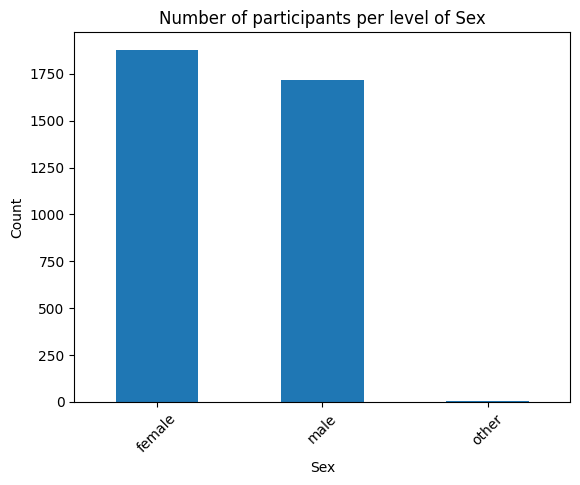

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# get sex counts
sex_counts = data["sex"].value_counts()

# Create Bar Plot
sex_counts.plot(kind="bar")
plt.title("Number of participants per level of Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

*Answer: You can for example look at this website: https://www.cbs.nl/en-gb/visualisations/dashboard-population/men-and-women
We see that in the Dutch population there are also a bit fewer men compared to women, just like in our dataset. Statistics of "Other" are not included in the CBS data.*

#### 3.9. Compare the distribution of Age in the dataset with the Dutch population. Do they differ? In what way?

We now explore how the distrubtion of "Age" differs between the group of people who donated their WhatsApp data and the group who did not. We do this by first creating a density plot.

/tmp/ipykernel_2740/1345681806.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


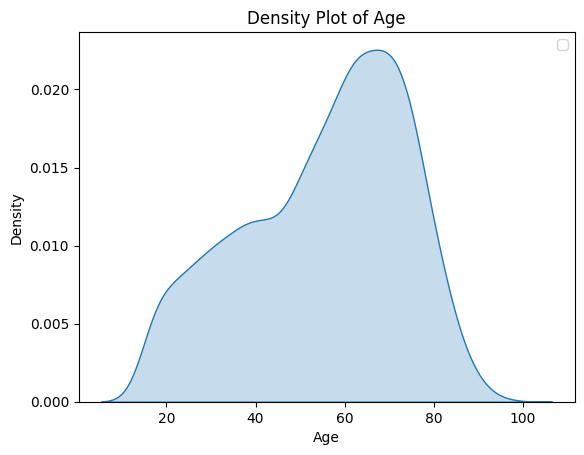

In [ ]:
# Density plot for age
sns.kdeplot(data["age"], fill=True)

# Add titles and labels
plt.title("Density Plot of Age")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()

# Show the plot
plt.show()

*Answer: To compare to CBS data, you can for example look here (https://www.cbs.nl/en-gb/visualisations/dashboard-population/age/age-distribution). People under the age of 16 are not included in the LISS panel, so it cannot be compared exactly. Furthermore, we see that a wide age distribution is covered in the sample, including even people up to 96 years of age. From the CBS data we can see that the large majority of people in the Netherlands is currently in the group 45-65, which we also see back in the distribution of our sample.*



#### 3.10. Compare the distribution of "Education" in the dataset with the Dutch population. Do they differ? In what way?

We now explore how the distrubtion of "Education" looks like in the sample. We do this by first creating a histogram.

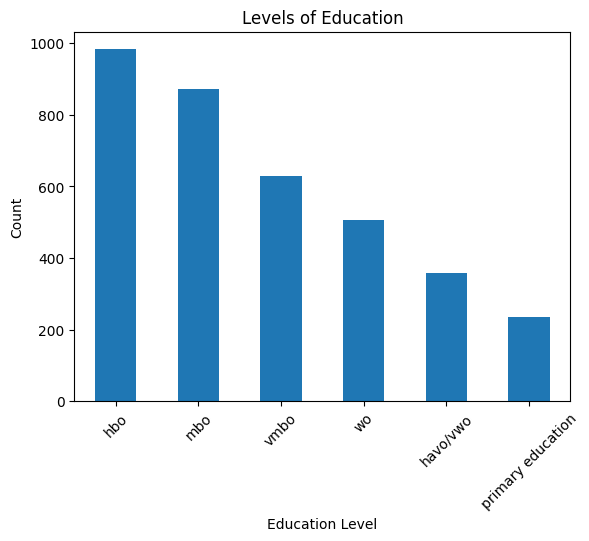

In [ ]:
# get education counts for individuals who did vs. did not donate
education_counts = data["education"].value_counts()

# Create Bar Plots for both
education_counts.plot(kind="bar")
plt.title("Levels of Education")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

*Answer: To compare to CBS data, you can for example look here: https://www.cbs.nl/nl-nl/cijfers/detail/85453NED?q=opleidingsniveau. It is a bit difficult to compare since CBS uses many more categories compared to LISS. However, we see few people both in LISS and CBS with "havo/vwo", more with "WO" in both, the biggest group being "HBO" followed by "MBO", and a small group with only "primary education".*

We now go back into the issue of nonresponse itself. If we dive into this dataset in more detail, we quickly see that the nonresponse is higher in specific parts of the data, especially the donated data.

#### 3.11. How many people donated their WhatsApp account data?

In [ ]:
print(data["did_donate_account"].value_counts())

did_donate_account
No     3249
Yes     349
Name: count, dtype: int64


*Answer: 349*

#### 3.12. What is the response percentage for the donation part of the observed sample?

In [ ]:
print(data["did_donate_account"].value_counts()["Yes"] / len(data) * 100)

9.699833240689273


*Answer: 9.7%*

There is more information available in this dataset to help us understand the mechanisms behind the nonresponse for this data donation part specifically. Before people started the data donation process, they were asked if they were willing to participate in the data donation part of the study.

#### 3.13. What can be reasons why people are not willing to donate their WhatsApp data?

*Answer:*
-	*They think the data is too sensitive to share.*
-	*They have privacy concerns or do not trust the researchers with this data.*
-	*They think the process will be too difficult or that it is too much effort.*


#### 3.14. How many people were willing to donate their WhatsApp data?

In [ ]:
print(data["consent"].value_counts())

no     2669
yes     929
Name: consent, dtype: int64


*Answer: 929*

#### 3.15. How many people indicated that they were willing to donate their WhatsApp data but did not donate in the end?

In [ ]:
print(pd.crosstab(data["consent"], data["did_donate_account"]))

did_donate_account    No  Yes
consent                      
no                  2669    0
yes                  580  349


*Answer: 580*

#### 3.16. What could be reasons why these people did not donate their data in the end?

*Potential answers:*
1.	*The participants thought the process was too difficult.*
2.	*The participants forgot to continue with the process after they needed to wait a couple of days before their data was ready.*
3.	*There could have been technical issues.*


We now investigate how the group of people who donated their WhatsApp data potentially differ from the group who did not donate their data with respect to the background characteristics we investigated earlier: sex, age and level of education.

#### 3.17. Is the distribution of Sex similar between the group that donated their WhatsApp data and the group who did not donate? Of not, in what way are they different?

In [ ]:
print(pd.crosstab(data["sex"], data["did_donate_account"]))

did_donate_account    No  Yes
sex                          
female              1702  176
male                1544  172
other                  3    1


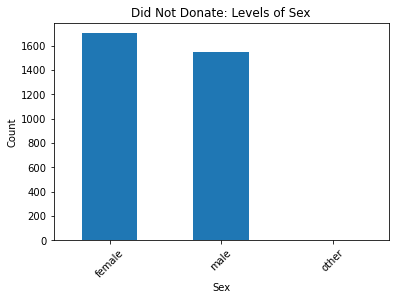

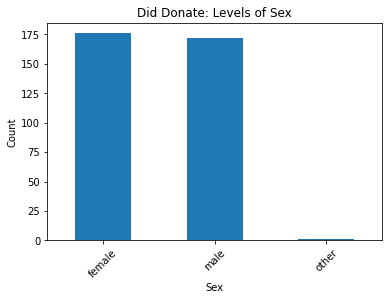

In [ ]:
# get sex counts for individuals who did vs. did not donate
sex_counts_nodon = data["sex"][data["did_donate_account"] == "No"].value_counts()
sex_counts_don = data["sex"][data["did_donate_account"] == "Yes"].value_counts()

# Create Bar Plots
sex_counts_nodon.plot(kind="bar")
plt.title("Did Not Donate: Levels of Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

sex_counts_don.plot(kind="bar")
plt.title("Did Donate: Levels of Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

*Answer: If we compare the two distributions, it seems that relatively a bit more males donated their data compared to females. In addition, it also seems that of the group "Other" 1 out of 4 donated their data, which makes a donation rate of 25% within that group.*

#### 3.18. Can you think of a difference between these two groups with respect to Sex?

*Answer: Maybe women consider themselves less tech savvy and therefore think they are not able to participate.*

#### 3.19. Is the distribution of Age similar between the group that donated their WhatsApp data and the group who did not donate? If not, in what way are they different?

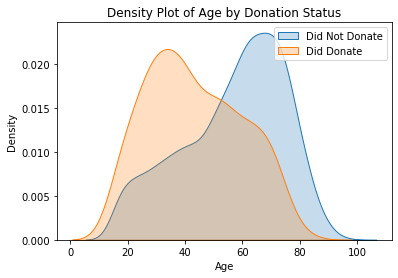

In [ ]:
# Density plot for those who did not donate
sns.kdeplot(data["age"][data["did_donate_account"] == "No"], label="Did Not Donate", fill=True)

# Density plot for those who did donate
sns.kdeplot(data["age"][data["did_donate_account"] == "Yes"], label="Did Donate", fill=True)

# Add titles and labels
plt.title("Density Plot of Age by Donation Status")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()

# Show the plot
plt.show()

*Answer: The group who donated their WhatsApp data and the group who did not donate are very different when it comes to their age distribution. We particularly see that the group who donated is younger compared to the group who did not donate. The group who did donate has a mean age of about 35 while the group who did not donate has a mean age of about 65.*

#### 3.20. Can you think of a reason for this difference between donated and not donated with respect to "Age"?

*Answer: Younger people might be more tech savvy and more comfortable carrying out the actions that are required to participate in a data donation study. In addition, older people might use platforms such as WhatsApp less often and as a result they might find their participation less useful.*

#### 3.20. Is the distribution of level of education similar between the group that donated their WhatsApp data and the group who did not donate? If not, in what way are they different?

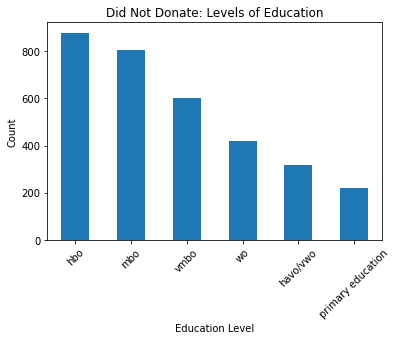

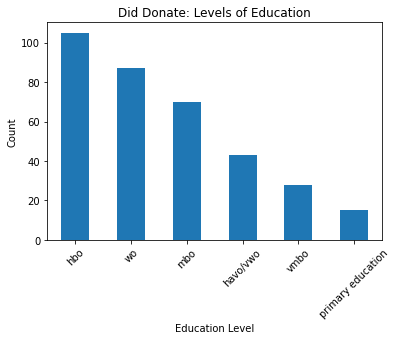

In [ ]:
# get education counts for individuals who did vs. did not donate
education_counts_nodon = data["education"][data["did_donate_account"] == "No"].value_counts()
education_counts_don = data["education"][data["did_donate_account"] == "Yes"].value_counts()

# Create Bar Plots for both
education_counts_nodon.plot(kind="bar")
plt.title("Did Not Donate: Levels of Education")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

education_counts_don.plot(kind="bar")
plt.title("Did Donate: Levels of Education")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

*Answer: It seems that in the group who did donate, there are relatively more higher educated people and relatively fewer lower education people.*

#### 3.21. Can you think of a reason for this difference between donated and not donated with respect to "Education"?

*Answer: Higher educated people might be more tech savvy, they might better understand the concept of data donation, or they might have more trust in institutions such as the LISS panel.*

## Part 4: Measurement issues

We now also explore what measurement issues might be present in this dataset. We continue to follow the Total Survey Error Framework by Groves et al. (2009), and dive into specific issues related to data donation when relevant.

### Validity

We start on the top of the measurement side of the TE framework with “Validity”.

#### 4.1. What is validity?

*Answer: Validity tells us to what extent we are actually measuring what we want to measure*

Now consider that we are interested in measuring social connectivity, we would like to understand how socially connected or embedded someone is within different communities, such as family, work, hobbies or their local environment. As an indicator for social connectivity, we use the number of WhatsApp group someone is a member of.

#### 4.2. How does what we want to measure differ from what we are actually measuring?

*Answer: People can have a lot of physical interactions with their environment that is not reflected by online interactions that take place in WhatsApp groups. Or they can have many online interactions on other platforms than WhatsApp.*

### Measurement error

#### 4.3.  What is measurement error?

*Answer: Measurement error tells us to what extent the measurements we obtain are correct.*

#### 4.4. We can obtain the number of WhatsApp groups a person is a member of in two different ways. The first way is by asking this in a survey (self-report). The second way is by extracting this number through data donation of the WhatsApp account. What can be reasons why these two numbers differ? Which of the two do you consider to be more reliable when considering what we are interested in for this study.

*Answer: In the self-reporting, people might do a rough estimate, while the donation shows the exact number. In that sense, the donation number is more accurate. Furthermore, people might forget about old groups in their self-report. Since no activity happens anymore, but there was in the past, it depends on whether the researcher is interested in “overall connectivity” or “current connectivity”. The number of WhatsApp groups through data donation is a good measurement for “overall connectivity”, but not so much for “current connectivity” because of these old groups. Finally, if participants have multiple WhatsApp groups with the same people, the measure obtained through data donation will overestimate, and the self-report will be more reliable.*


We now explore how the distribution of donated number of groups compares to the distribution of the self-reported number of groups

#### 4.5. How does the distribution of the donated number of groups differ from the self-reported number of groups?

count    2831.00000
mean       10.45461
std        17.44062
min         0.00000
25%         3.00000
50%         6.00000
75%        10.00000
max       400.00000
Name: groups_quest, dtype: float64


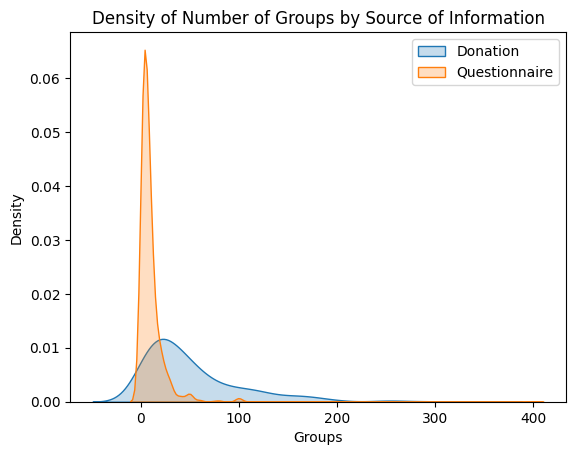

In [ ]:
print(data["groups_quest"].describe())

# Plot
sns.kdeplot(data["groups_don"], label = "Donation", fill = True)
sns.kdeplot(data["groups_quest"], label = "Questionnaire", fill = True)

# Add titles and labels
plt.title("Density of Number of Groups by Source of Information")
plt.xlabel("Groups")
plt.ylabel("Density")
plt.legend()

# Show the plot
plt.show()

*Answer: In the self-report question, a few people largely overestimated and filled in a very high number, but the majority of the people filled in relatively low numbers, as a result this distribution has a large peek but also a wider range. In comparison, the donated data shows more variation but the values are less extreme.*

If there were no differences between these two variables, they would have a correlation of 1.

#### 4.6. What is the correlation coefficient between these two variables?

0.5421788780261098


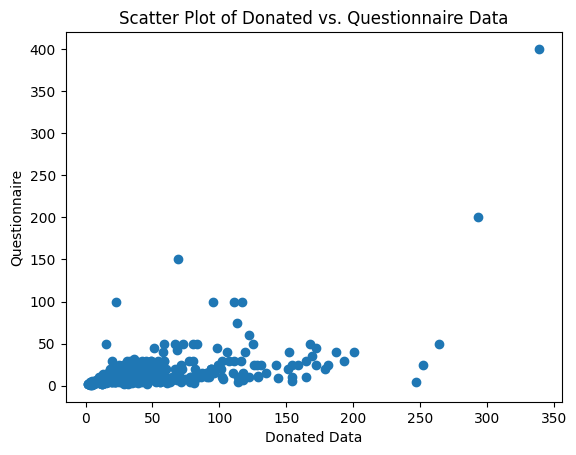

In [ ]:
# Correlation
correlation = data[["groups_don", "groups_quest"]].dropna().corr().iloc[0, 1]
print(correlation)

# Plot
plt.scatter(data["groups_don"], data["groups_quest"])
plt.xlabel("Donated Data")
plt.ylabel("Questionnaire")
plt.title("Scatter Plot of Donated vs. Questionnaire Data")
plt.show()

*Answer: 0.54*

#### 4.7. How would you interpret this correlation?

*Answer: Following the plot and correlation coefficient we can conclude that self-reported and donated data differ, but there is a moderate correlation between the two. This means that to a certain extent people can do a very rough estimate of their number of WhatsApp groups. The plot furthermore shows that people are likely to underestimate their number of WhatsApp groups.*

### Processing error

#### 4.8. What is processing error?

*Answer: The difference between the obtained response and the data used after making various edits.*

Consider the number of WhatsApp groups we obtained through data donation. In this study, data donation was performed using local processing. This means that the participant's device counted the number of WhatsApp groups locally, and only this count was shared with LISS. The raw WhatsApp groups were never shared with LISS.

#### 4.9. What is the consequence of this local processing step when considering the processing error here?

*Answer: If there were errors made in local processing, we can only find them in the responses that we received. As a result, we cannot distinguish between measurement error and this form of processing error.*

#### 4.10. What other forms of processing errors can you think of?

*Answer: Other forms of processing error can occur when the data is for example cleaned, merged, or when missing data is handled.*

## Part 5: Amplified asking

What we want to do now, is creating a model to predict the number of WhatsApp groups provided in the donated data using the survey variables as predictors. To do that,	we only take the part where we have observations for both the survey and the donations.

First of all, we need to subset the data to respondents who also donated their WhatsApp data, as we need observations with values in the dependent variable to estimate the model.

In [ ]:
# Subset data to people who donated
data_don = data[data['groups_don'].notna()]

Next, we estimate an OLS regression model to predict *groups_don*. We first only use the self-reported number of groups (i.e., *groups_quest*) as predictor which further illustrates the relationship between the two variables. Next, we include other survey variables, i.e. *sex*, *age*, *education* in the model as well.

In [ ]:
import statsmodels.formula.api as sm

# model only including self-reported groups
model_selfrep = sm.ols(formula="groups_don ~ groups_quest", data=data_don).fit()
print(model_selfrep.summary())

# model including other survey variables
model_full = sm.ols(formula="groups_don ~ sex + age + education + groups_quest", data=data_don).fit()
print(model_full.summary())


                            OLS Regression Results                            
Dep. Variable:             groups_don   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     128.7
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           3.66e-25
Time:                        10:28:24   Log-Likelihood:                -1619.5
No. Observations:                 311   AIC:                             3243.
Df Residuals:                     309   BIC:                             3251.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       36.9725      2.911     12.702   

#### 5.1. Looking at the model output, which of the two models should we continue with? Reason your decision with a statistic from the output.

*Answer: For example, looking at the R-squared value, we see that more variance in the outcome variable “groups_don” is explained when background characteristics (e.g., sex and age) are included in the model alongside the self-reported number of groups.*

Next, we can look at how well the predicted values from the full model for people who donated match with the actual donated values. To do so, we plot them against each other below.

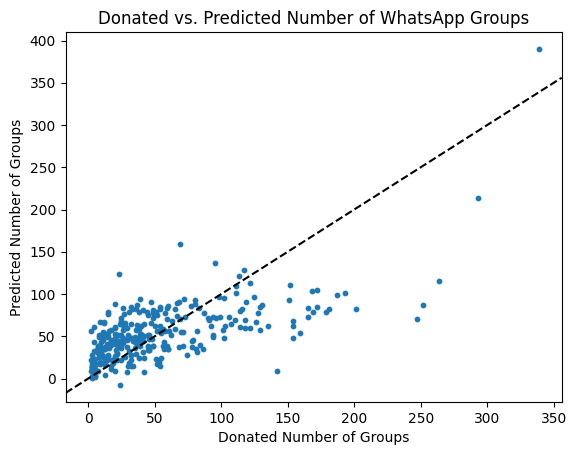

In [ ]:
# Scatter plot donated and predicted data
plt.scatter(data_don["groups_don"], model_full.predict(data_don), s=10)

# Add diagonal dashed line
plt.axline((0, 0), slope=1, color="black", linestyle="--")

# Add titles and labels
plt.xlabel("Donated Number of Groups")
plt.ylabel("Predicted Number of Groups")
plt.title("Donated vs. Predicted Number of WhatsApp Groups")

# Show the plot
plt.show()


Additionally we can again look at the densities

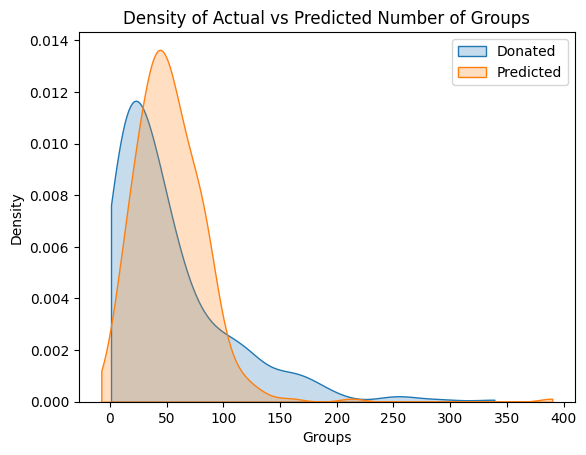

In [ ]:
# Plot densities
sns.kdeplot(data_don["groups_don"], label = "Donated", fill = True, cut=0)
sns.kdeplot(model_full.predict(data_don), label = "Predicted", fill = True, cut=0)

# Add titles and labels
plt.title("Density of Actual vs Predicted Number of Groups")
plt.xlabel("Groups")
plt.ylabel("Density")
plt.legend()

# Show the plot
plt.show()


#### 5.2. Inspecting the two plots above, what do you notice about the predicted values? Does the model predict the number of groups well?

*Answer: The model predictions are a bit higher than donated groups for people with relatively few groups, while the predictions are lower than the donated groups when the donated groups are more.
From the densities we can also conclude that in the donated data, we find more people that have very few or a lot of groups in comparison to the model predictions. However, overall, they are quite close.*

We can now run a cross-validation:

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

# Only keep complete observations (listwise deletion)
X = data_don[["sex", "age", "education", "groups_quest"]].dropna()
y = data_don["groups_don"][X.index]

# Create label encoder for the categorical variables
le = LabelEncoder()

# Fit and transform the categorical variables
X["sex"] = le.fit_transform(X["sex"]) # convert sex to numeric values
X["education"] = le.fit_transform(X["education"]) # convert education to numeric values

# Estimate linear model
model = LinearRegression()

# Perform cross-validation
r2_scores = cross_val_score(model, X, y, cv=5, scoring= "r2")

# Retrieve r2 values per fold
print("R2 scores:", r2_scores)
print("Average R2 score:", r2_scores.mean())



R2 scores: [0.17839802 0.18656432 0.02879055 0.39972704 0.39857481]
Average R2 score: 0.23841094846299066


And then use the estimated model to predict the number of groups for participants who did not donate their Whatsapp groups.

In [ ]:
# Subset to people who have values for all survey variables & didn't donate
data_survey = data[data['groups_don'].isna() & data[['sex', 'age', 'education', 'groups_quest']].notna().all(axis=1)]

# Select predictor variables
X_new = data_survey[["sex", "age", "education", "groups_quest"]]

# Fit and transform the categorical variables
X_new["sex"] = le.fit_transform(X_new["sex"])
X_new["education"] = le.fit_transform(X_new["education"])

# Estimate linear model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X_new)

# Add predictions to the data_survey
data_survey['groups_don_pred'] = y_pred

print(data_survey.head())

  consent did_donate_account     sex  age education  groups_don  groups_quest  \
1      no                 No    male   60        wo         NaN           6.0   
3      no                 No  female   32       mbo         NaN           1.0   
5     yes                 No  female   39       mbo         NaN          10.0   
6      no                 No  female   69       mbo         NaN           2.0   
7      no                 No  female   48       mbo         NaN           4.0   

   groups_don_pred  
1        38.083152  
3        42.462145  
5        43.099031  
6         6.960046  
7        29.252777  


/tmp/ipykernel_2740/178005021.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_new["sex"] = le.fit_transform(X_new["sex"])
/tmp/ipykernel_2740/178005021.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_new["education"] = le.fit_transform(X_new["education"])
/tmp/ipykernel_2740/178005021.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydat

Lastly, we can compare the distribution of Whatsapp groups of the actual data from the donation and the predictions from our model:

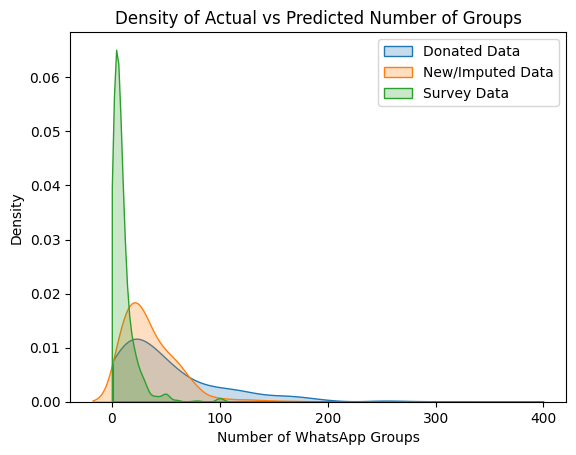

In [ ]:
# concatenate data_don["groups_don"] and data_survey['groups_don_pred']
data_all = pd.concat([data_don["groups_don"], data_survey['groups_don_pred']])

# density plot for actual donated values
sns.kdeplot(data_don["groups_don"], label="Donated Data", fill = True, cut=0)

# density plot for predicted donated values
sns.kdeplot(data_all, label="New/Imputed Data", fill = True, cut=0)

# density plot for the survey group
sns.kdeplot(data["groups_quest"], label="Survey Data", fill = True, cut=0)

# Add titles and labels
plt.title("Density of Actual vs Predicted Number of Groups")

plt.xlabel("Number of WhatsApp Groups")
plt.ylabel("Density")
plt.legend()
plt.show()


#### 5.3. Describe in your own words which steps we carried out in the pieces of code above.

*Answer: We have first selected only the part of the data that contained both donations and survey answers. We removed the part that had no donated data. We then created a prediction model on this part of the data where we tried to predict the “number of donated groups” based on multiple survey variables. We inspected the resulting predictions here and performed cross-validation. Next, we used that model in the part of the dataset that did not have any donations for the number of groups, and we predicted the number of groups for this subset of the data.*

#### 5.4. How can we use this new predicted/imputed variable?

*Answer: With this new variable, we can make estimates for the number of WhatsApp groups for the complete survey sample based on donated data, not only for the subsample of the people who actually donated their data.*

#### 5.5. Compare the distribution of the number of groups from the survey group to the new group. How do they differ?

*Answer: The new data is somewhat in between the survey data and the donated data. It seems to have less extreme values compared to the survey data, but has a bit of a lower average compared to the subsample with donations.*

#### 5.6. As we found out earlier, the average of the predicted values for "donated number of groups" is a bit lower compared to the average in the observed values for "donated number of groups". Consider the information that we incorporate in our prediction model here. What can be an explanation for this difference?

*Answer: We included variables such as age and level of education which appeared to be related to donation. So older people were less likely to donate. If this is also related to the number of groups they are a member of (and this is less), then it makes sense that we see this in a difference between the two distributions as well.*

#### 5.7. We now have a variable that contains both the "donated number of groups" as well as the "predicted donated number of groups" for the participants that did not donate. In what way can this variable lead to estimates of better quality (less error) compared to when only the "donated number of groups" was being used?

*Answer: It takes into account that certain demographic groups are less likely to donate, and that the number of WhatsApp groups they are a member of might be different for these demographic groups.*

#### 5.8. And in what way could using such a variable lead to estimats of lower quality?

*Answer: Such predictions do not account for the quality of the prediction model. We saw earlier that it was not perfect. In addition, the model can also not be 100% certain that the predictions are correct, and this uncertainty should be reflected in variance estimates.*

## Part 6: Literature questions

#### 6.1. Read through [this](https://royalsocietypublishing.org/doi/pdf/10.1098/rsif.2015.0185) paper as well as Section 3.6.2 in the Bit by Bit book. What are the similarities between the study design of Toole et al. (2015) with that of Blumenstock et al. (2015)?

*Answer: Both studies make use of big data in the form of call records, and both aim to create a model with this data that can estimate statistics that are currently being estimated with surveys.*

#### 6.2. And what are the differences?

*Answer: Where Blumenstock makes use of survey data to build the model and to investigate the performance of their model (Truly amplefied asking as it is described in the book), Toole and colleagues did not use a smaller data set that functioned as a bench mark. They make use of general information on the community level (e.g., how many people were laid off), but they don't validate their findings on the invidual level like Blumenstock does.*

*Another difference is that Toole and colleagues also have the goal to predict lay off at a later moment in time, where Blumenstock's research was more aimed at only estimating a real time statistic for the population.*

#### 6.3. Do you think call records should replace traditional surveys, complement them, or not to be used at all for government policymakers to track unemployment. Why?

*Answer: As call records are only a proxy variable for unemployment, surveys can provide correcter measurements. The work of Toole et al shows that the call records can have other advantages than survey data. Therefore, using records to complements survey data would be best: costs can be lowered and data can be collected in a shorter period of time when using call records, leading to quicker policy implementations. Surveys can then be used to evaluate policies and evaluate the accuracy of the use of call records.*

*Note that your answers might describe another opinion.*

#### 6.4. What evidence would convince you that call detail records can completely replace traditional survey measures of unemployment rate?

*Answer: The current study assumes that the model used is generalizable to other situations or places. For call records to completely replace traditional surveys, I would like evidence that the call records can predict unemployment correctly at different situations (e.g. different types of companies), different citties, and in different moment in time.*

*However, call behaviour might change over time, potentially leading to another relation to unemployment rates over time. Therefore, even if there was evidence that call records can replace survey data in a broad range of situations, survey data should be used to keep evaluating the current accuracy and performance of the model.*


*Note that your answers might describe another opinion than the one described in this answer model.*